92 daily files in window
185 soundings between 2025-09-01 and 2025-12-01


/tmp/ipykernel_82037/2862888397.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


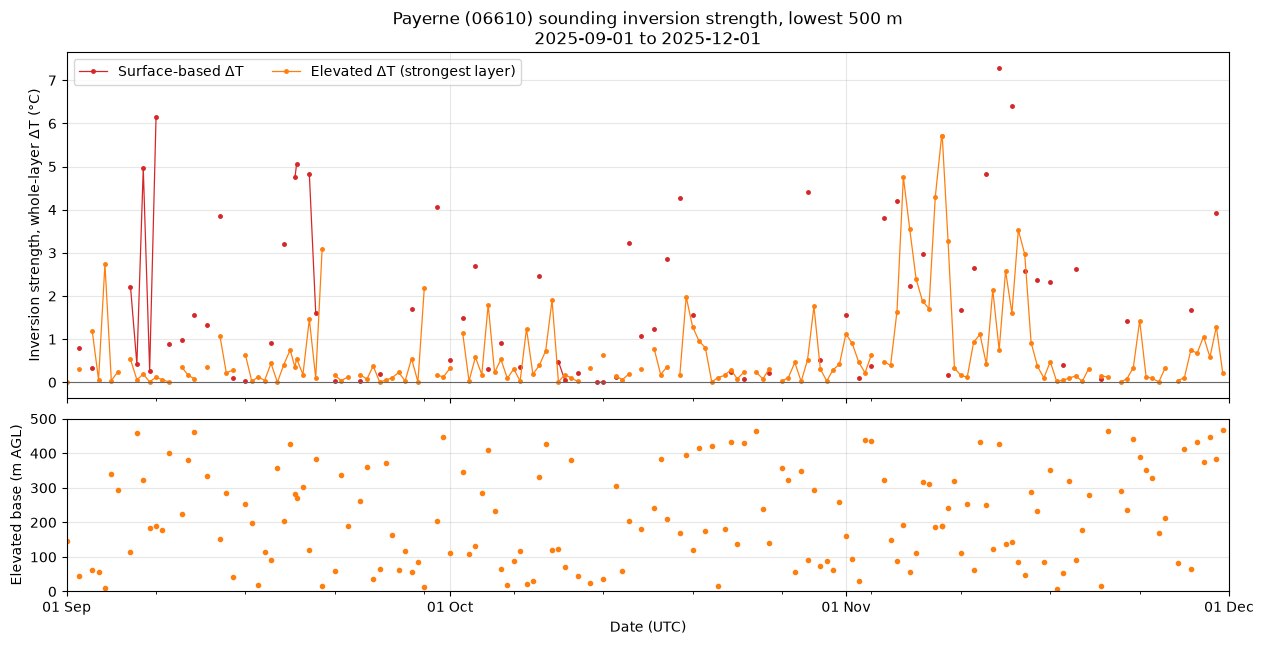


soundings with a surface-based inversion: 71 / 185  (max ΔT 7.3 °C)
soundings with an elevated inversion:     161 / 185  (max ΔT 5.7 °C)

monthly mean ΔT (no-inversion counted as 0):
            surface  elevated
termin                       
2025-09-01      NaN       NaN
2025-10-01      NaN       NaN
2025-11-01      NaN       NaN


In [2]:
# ==========================================================
# STANDALONE CELL
# Surface-based (ground) vs elevated inversion strength
# Payerne soundings, 2025-09-01 -> 2025-12-01
# ==========================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ----------------------------------------------------------
# CONFIG
# ----------------------------------------------------------
SOUNDINGS_DIR = Path("/scratch/mch/jdelbeke/soundings/output")
STATION_ID    = "06610"
MAX_HEIGHT_M  = 500
MISSING_VALUE = 10000000
TERMIN_FMT    = "%Y%m%d%H%M%S"

EMBED_TOLERANCE_M = 10
MIN_LAYER_DEPTH_M = EMBED_TOLERANCE_M

PLOT_START = pd.Timestamp("2025-09-01")
PLOT_END   = pd.Timestamp("2025-12-01")          # exclusive

# A sounding with no detected layer is a *measurement of no inversion*,
# not missing data -> plot it as 0 so the line stays continuous.
# Set to False if you prefer gaps.
NO_INVERSION_AS_ZERO = False

# Restrict to specific launch hours (UTC), e.g. [0] or [0, 12]; None = all.
HOURS = None

# ----------------------------------------------------------
# HELPERS  (unchanged from your notebook)
# ----------------------------------------------------------
def parse_termin(x):
    return pd.to_datetime(str(x), format=TERMIN_FMT)


def read_sounding(file):
    with open(file) as f:
        header = f.readlines()[1].split()
    return pd.read_csv(
        file, sep=r"\s*\|\s*", engine="python",
        skiprows=3, header=None, names=header,
    )


def load_profiles(file):
    df = read_sounding(file)
    df["termin"] = df["termin"].astype(str).apply(parse_termin)
    profiles = {}
    for termin, sounding in df.groupby("termin"):
        profile = (
            sounding[["742", "745"]]
            .replace(MISSING_VALUE, np.nan)
            .dropna()
            .rename(columns={"742": "height", "745": "temperature"})
            .sort_values("height")
        )
        if profile.empty:
            continue
        profile["height"] -= profile["height"].iloc[0]
        profile = (profile.groupby("height", as_index=False)["temperature"]
                          .mean().sort_values("height"))
        profiles[termin] = profile
    return profiles


def find_inversion_layers(profile, max_height=MAX_HEIGHT_M,
                          embed_tolerance_m=EMBED_TOLERANCE_M,
                          min_depth_m=MIN_LAYER_DEPTH_M):
    prof = profile[profile["height"] <= max_height]
    z, T = prof["height"].values, prof["temperature"].values
    n = len(z)
    if n < 3:
        return []
    layers, i = [], 0
    while i < n - 1:
        base = top = i
        j = i + 1
        while j < n:
            if T[j] >= T[top]:
                top = j
                j += 1
            elif z[j] - z[top] <= embed_tolerance_m:
                j += 1
            else:
                break
        depth = z[top] - z[base]
        if top > base and depth >= min_depth_m:
            layers.append({
                "base_height": z[base], "top_height": z[top],
                "depth": depth, "deltaT": T[top] - T[base],
                "mean_gradient": (T[top] - T[base]) / depth,
                "surface_based": z[base] == 0,
            })
            i = top + 1
        else:
            i += 1
    return layers


# ----------------------------------------------------------
# BUILD THE TABLE  (only files inside the plotting window)
# ----------------------------------------------------------
def file_date(f):
    try:
        return pd.Timestamp(f.name[:8])
    except ValueError:
        return pd.NaT


files = [
    f for f in sorted(SOUNDINGS_DIR.glob(f"*_{STATION_ID}_data.txt"))
    if pd.notna(file_date(f))
    and PLOT_START - pd.Timedelta(days=1) <= file_date(f) <= PLOT_END
]
print(f"{len(files)} daily files in window")

rows = []
for file in files:
    try:
        profiles = load_profiles(file)
    except Exception as err:                       # keep going on a bad file
        print(f"  skipped {file.name}: {err}")
        continue

    for termin, profile in profiles.items():
        if not (PLOT_START <= termin < PLOT_END):
            continue
        if HOURS is not None and termin.hour not in HOURS:
            continue

        layers   = find_inversion_layers(profile)
        surface  = next((l for l in layers if l["surface_based"]), None)
        elevated = max((l for l in layers if not l["surface_based"]),
                       key=lambda l: l["deltaT"], default=None)

        rows.append({
            "termin":           termin,
            "surface_deltaT":   surface["deltaT"] if surface else np.nan,
            "surface_depth":    surface["depth"] if surface else np.nan,
            "elevated_deltaT":  elevated["deltaT"] if elevated else np.nan,
            "elevated_height":  elevated["base_height"] if elevated else np.nan,
            "elevated_depth":   elevated["depth"] if elevated else np.nan,
        })

ts = pd.DataFrame(rows).sort_values("termin").reset_index(drop=True)
print(f"{len(ts)} soundings between {PLOT_START:%Y-%m-%d} and {PLOT_END:%Y-%m-%d}")

if ts.empty:
    raise SystemExit("No soundings found in the requested window.")

surface_series  = ts["surface_deltaT"]
elevated_series = ts["elevated_deltaT"]
if NO_INVERSION_AS_ZERO:
    surface_series  = surface_series.fillna(0.0)
    elevated_series = elevated_series.fillna(0.0)

# ----------------------------------------------------------
# PLOT
# ----------------------------------------------------------
fig, (ax_dt, ax_h) = plt.subplots(
    2, 1, figsize=(15, 7), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
)

ax_dt.plot(ts["termin"], surface_series, marker="o", markersize=2.5,
           linewidth=0.9, color="tab:red", label="Surface-based ΔT")
ax_dt.plot(ts["termin"], elevated_series, marker="o", markersize=2.5,
           linewidth=0.9, color="tab:orange", label="Elevated ΔT (strongest layer)")
ax_dt.axhline(0, color="0.4", linewidth=0.8)
ax_dt.set_ylabel("Inversion strength, whole-layer ΔT (°C)")
ax_dt.set_title(
    f"Payerne ({STATION_ID}) sounding inversion strength, lowest {MAX_HEIGHT_M} m\n"
    f"{PLOT_START:%Y-%m-%d} to {PLOT_END:%Y-%m-%d}"
)
ax_dt.legend(loc="upper left", ncol=2)
ax_dt.grid(alpha=0.3)

ax_h.plot(ts["termin"], ts["elevated_height"], linestyle="none",
          marker="o", markersize=3, color="tab:orange")
ax_h.set_ylabel("Elevated base (m AGL)")
ax_h.set_ylim(0, MAX_HEIGHT_M)
ax_h.grid(alpha=0.3)

ax_h.xaxis.set_major_locator(mdates.MonthLocator())
ax_h.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax_h.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax_h.set_xlim(PLOT_START, PLOT_END)
ax_h.set_xlabel("Date (UTC)")

fig.tight_layout()
plt.show()

# ----------------------------------------------------------
# QUICK SUMMARY
# ----------------------------------------------------------
print(
    "\nsoundings with a surface-based inversion: "
    f"{ts['surface_deltaT'].notna().sum()} / {len(ts)}"
    f"  (max ΔT {ts['surface_deltaT'].max():.1f} °C)"
)
print(
    "soundings with an elevated inversion:     "
    f"{ts['elevated_deltaT'].notna().sum()} / {len(ts)}"
    f"  (max ΔT {ts['elevated_deltaT'].max():.1f} °C)"
)
print("\nmonthly mean ΔT (no-inversion counted as 0):")
print(
    pd.DataFrame({"surface": surface_series, "elevated": elevated_series},
                 index=ts["termin"])
    .resample("MS").mean().round(2)
)